In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from numpy import hstack, arange, meshgrid, where
from plot_classification_surface import plot_classification_surface
from sklearn.metrics import confusion_matrix, roc_auc_score, classification_report, roc_curve 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from calculate_metrics import calculate_metrics
from sklearn.svm import SVC
import warnings

In [4]:

diabetes = pd.read_csv('diabetes.csv')
scaler_2var = StandardScaler()


In [5]:
features = ['Pregnancies','PlasmaGlucose','DiastolicBloodPressure','TricepsThickness','SerumInsulin','BMI','DiabetesPedigree','Age']
target = 'Diabetic'
X, y = diabetes[features], diabetes[target]
X_train, X_test, y_train, y_test = train_test_split(X[['Pregnancies', 'Age']], y, test_size=0.30, random_state=0, stratify=y)
X_train_standardized = scaler_2var.fit_transform(X_train)
X_test_standardized = scaler_2var.transform(X_test)


c:\Users\abram\Desktop\Kodilla\learning-git-task\14.Klasyfikacja\plot_classification_surface.py:32: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_plot[row_ix,0], X_plot[row_ix,1], cmap='Paired', alpha=0.3, label= class_value)


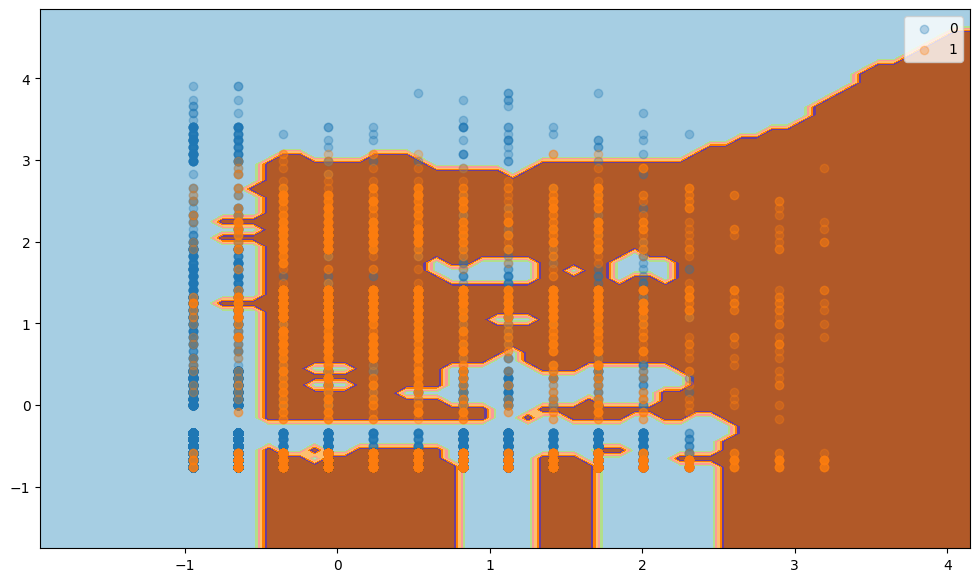

              precision    recall  f1-score   support

           0       0.90      0.91      0.91      3000
           1       0.81      0.80      0.81      1500

    accuracy                           0.87      4500
   macro avg       0.86      0.86      0.86      4500
weighted avg       0.87      0.87      0.87      4500



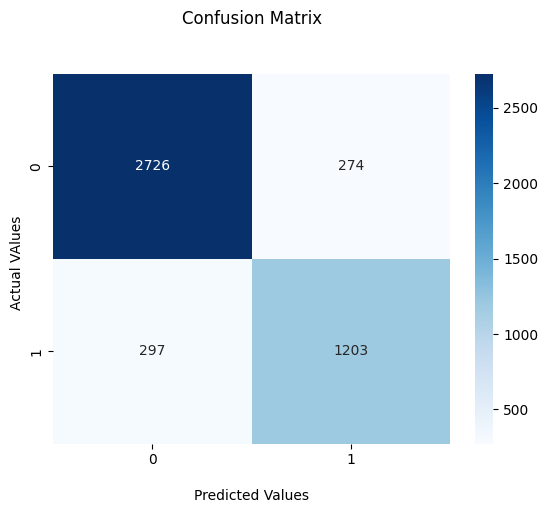

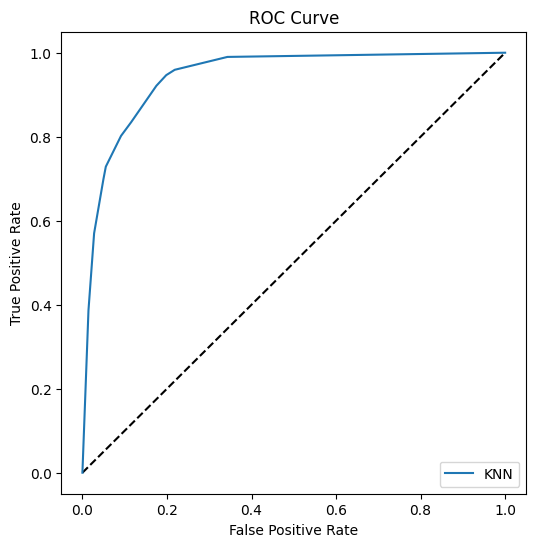

,Model,F1_score,AUC
0,KNN,0.808196,0.942804


In [6]:
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier(n_neighbors = int(X_train_standardized.shape[0]*0.001))
model_knn.fit(X_train_standardized, y_train)
plot_classification_surface(X_plot=X_train_standardized, y_plot=y_train, trained_model=model_knn)
calculate_metrics(model_knn, 'KNN', X_test_standardized, y_test)

In [7]:
# help(KNeighborsClassifier)

for - KNN_n-1_p-1
F1 train: 0.8020790589522637
F1 test : 0.7834658187599364
for - KNN_n-2_p-1
F1 train: 0.7729133858267716
F1 test : 0.7546212395795578
for - KNN_n-3_p-1
F1 train: 0.818957080945058
F1 test : 0.8007825236387349
for - KNN_n-4_p-1
F1 train: 0.7897451930592465
F1 test : 0.7789397764154345
for - KNN_n-5_p-1
F1 train: 0.8128560993425858
F1 test : 0.8009430784776019
for - KNN_n-6_p-1
F1 train: 0.8106626047220107
F1 test : 0.8005608131791097
for - KNN_n-7_p-1
F1 train: 0.8298850574712644
F1 test : 0.8162180126287804
for - KNN_n-8_p-1
F1 train: 0.820076313472263
F1 test : 0.8105906313645621
for - KNN_n-9_p-1
F1 train: 0.8149842722333429
F1 test : 0.8031651829871415
for - KNN_n-1_p-2
F1 train: 0.8020790589522637
F1 test : 0.7834658187599364
for - KNN_n-2_p-2
F1 train: 0.7729133858267716
F1 test : 0.7546212395795578
for - KNN_n-3_p-2
F1 train: 0.818957080945058
F1 test : 0.8007825236387349
for - KNN_n-4_p-2
F1 train: 0.7897451930592465
F1 test : 0.7789397764154345
for - KNN_n-5_p

c:\Users\abram\Desktop\Kodilla\learning-git-task\14.Klasyfikacja\plot_classification_surface.py:32: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_plot[row_ix,0], X_plot[row_ix,1], cmap='Paired', alpha=0.3, label= class_value)


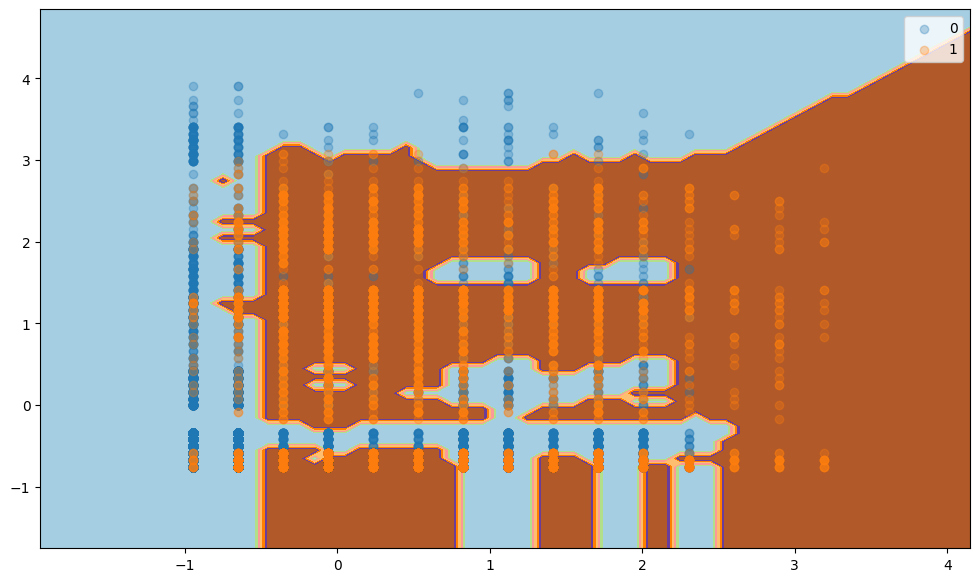

              precision    recall  f1-score   support

           0       0.91      0.91      0.91      3000
           1       0.81      0.82      0.82      1500

    accuracy                           0.88      4500
   macro avg       0.86      0.86      0.86      4500
weighted avg       0.88      0.88      0.88      4500



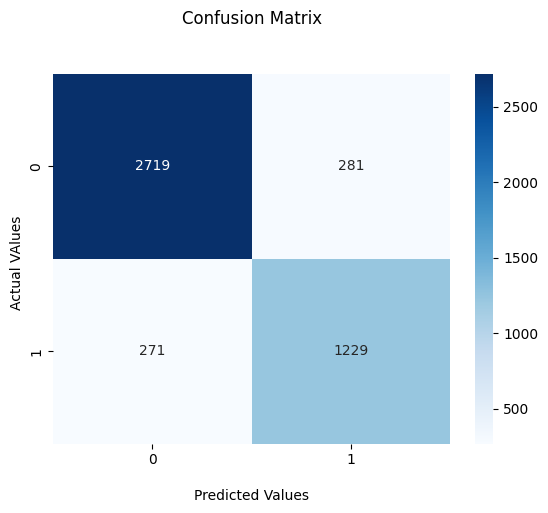

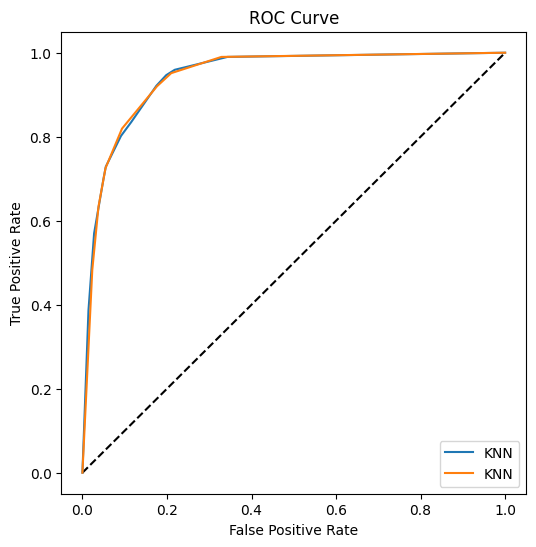

Lowest score


c:\Users\abram\Desktop\Kodilla\learning-git-task\14.Klasyfikacja\plot_classification_surface.py:32: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_plot[row_ix,0], X_plot[row_ix,1], cmap='Paired', alpha=0.3, label= class_value)


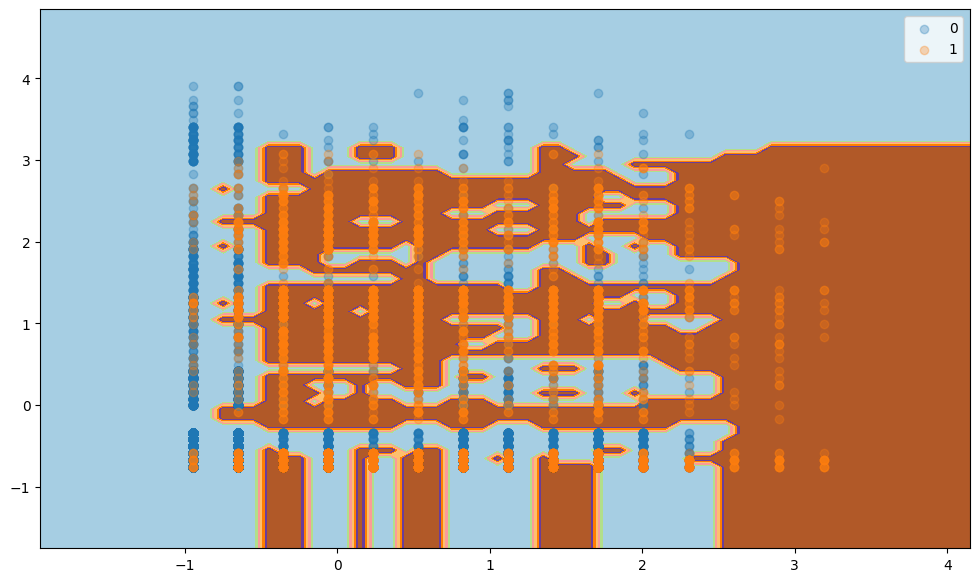

              precision    recall  f1-score   support

           0       0.86      0.93      0.89      3000
           1       0.83      0.69      0.75      1500

    accuracy                           0.85      4500
   macro avg       0.84      0.81      0.82      4500
weighted avg       0.85      0.85      0.85      4500



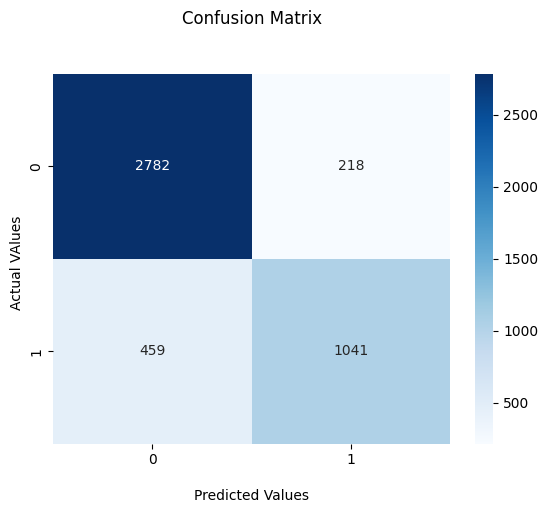

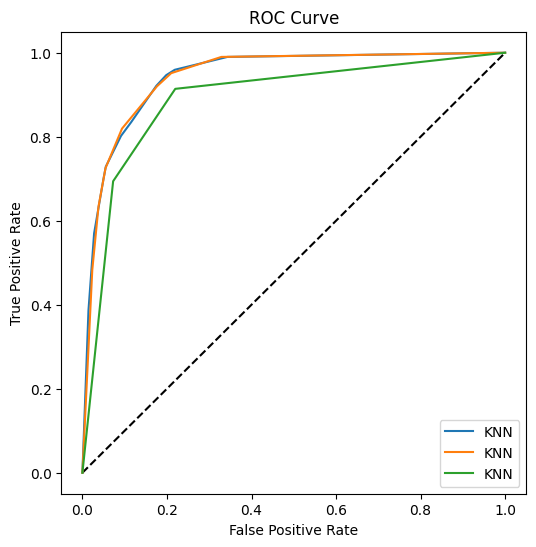

,Model,F1_score,AUC
0,KNN,0.808196,0.942804
1,KNN,0.816611,0.941814
2,KNN,0.754621,0.890182


In [8]:
best_f1_score_test = -1
lowest_f1_score_test = 10
for p in range(1,4):
    for n in range(1,10):
        name = f'KNN_n-{n}_p-{p}'
        model_knn = KNeighborsClassifier(n_neighbors=n, metric='minkowski', p=p)
        model_knn.fit(X_train_standardized, y_train)
        prediction_train = model_knn.predict(X_train_standardized)
        prediction_test = model_knn.predict(X_test_standardized)
        f1_score_train = f1_score(y_train, prediction_train)
        f1_score_test = f1_score(y_test, prediction_test)
        print(f'for - {name}')
        print('F1 train:', f1_score_train)
        print('F1 test :', f1_score_test)
        if f1_score_test > best_f1_score_test:
            best_f1_score_test = f1_score_test
            best_name = name
        if f1_score_test < lowest_f1_score_test:
            lowest_f1_score_test = f1_score_test
            lowest_name = name
        

print('for:  ',best_name,'\nBest score F1 test = ', best_f1_score_test)
print('for:  ',lowest_name,'\nLowest score F1 test = ', lowest_f1_score_test)

print('Best score')
model_knn = KNeighborsClassifier(n_neighbors=7, metric='minkowski', p=2)
model_knn.fit(X_train_standardized, y_train)
plot_classification_surface(X_plot=X_train_standardized, y_plot=y_train, trained_model=model_knn)
calculate_metrics(model_knn, 'KNN', X_test_standardized, y_test)
print('Lowest score')
model_knn = KNeighborsClassifier(n_neighbors=2, metric='minkowski', p=1)
model_knn.fit(X_train_standardized, y_train)
plot_classification_surface(X_plot=X_train_standardized, y_plot=y_train, trained_model=model_knn)
calculate_metrics(model_knn, 'KNN', X_test_standardized, y_test)
        

In [9]:
from sklearn.tree import DecisionTreeClassifier

model_tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=int(X_train.shape[0]*0.001))
model_tree.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

c:\Users\abram\Desktop\Kodilla\learning-git-task\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


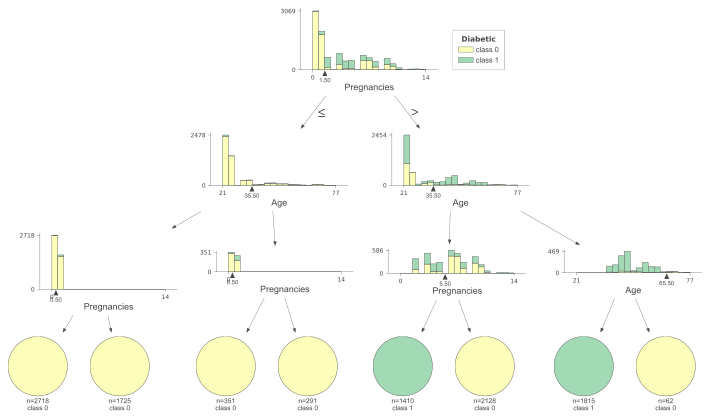

In [10]:
from dtreeviz import trees
viz = trees.dtreeviz(model_tree, x_data=X_train, y_data=y_train,target_name='Diabetic', feature_names = X_train.columns)
viz


c:\Users\abram\Desktop\Kodilla\learning-git-task\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\abram\Desktop\Kodilla\learning-git-task\14.Klasyfikacja\plot_classification_surface.py:32: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_plot[row_ix,0], X_plot[row_ix,1], cmap='Paired', alpha=0.3, label= class_value)


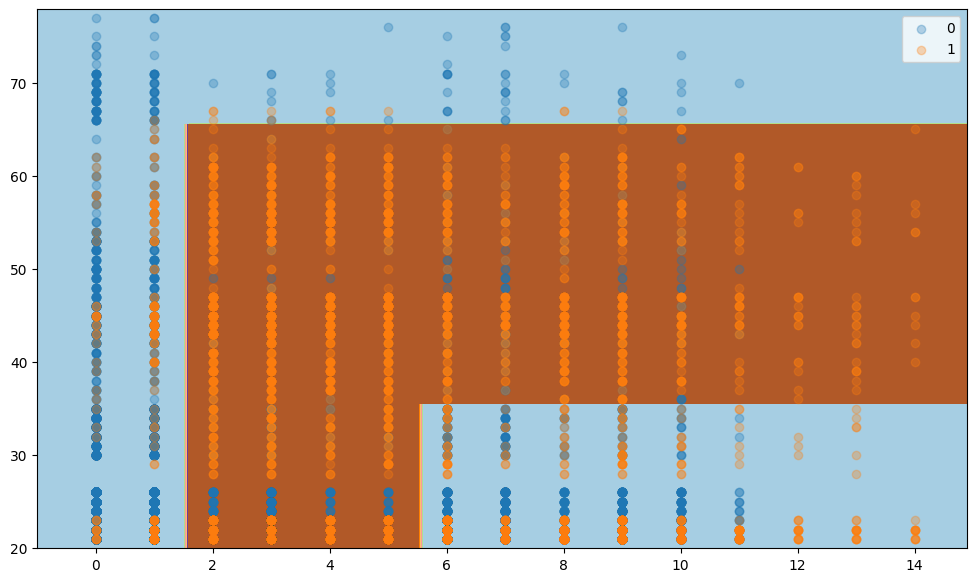

              precision    recall  f1-score   support

           0       0.88      0.91      0.89      3000
           1       0.80      0.76      0.78      1500

    accuracy                           0.86      4500
   macro avg       0.84      0.83      0.84      4500
weighted avg       0.86      0.86      0.86      4500



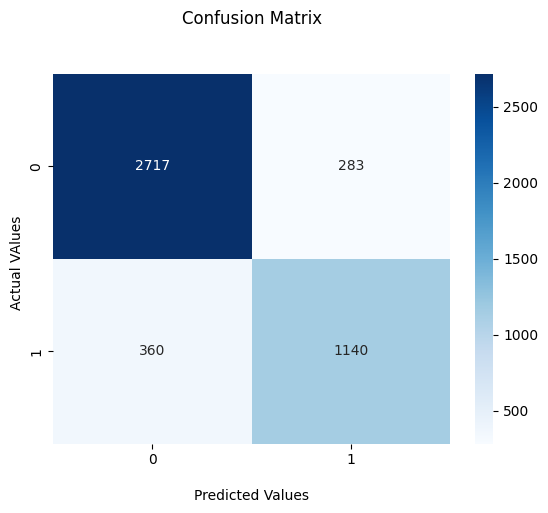

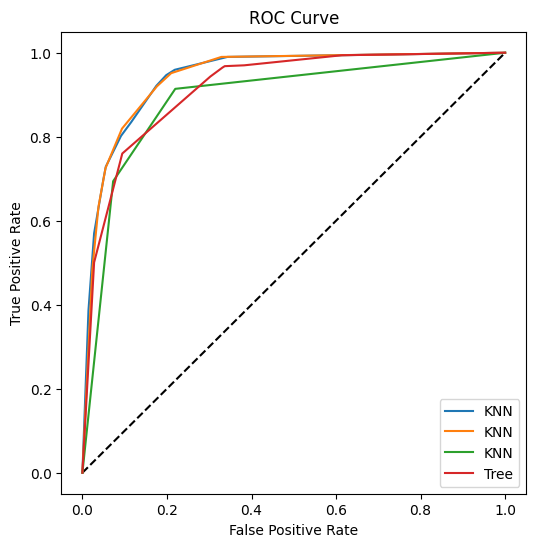

,Model,F1_score,AUC
0,KNN,0.808196,0.942804
1,KNN,0.816611,0.941814
2,KNN,0.754621,0.890182
3,Tree,0.780021,0.915466


In [11]:
plot_classification_surface(X_plot=np.array(X_train), y_plot=y_train, trained_model=model_tree)
calculate_metrics(model_tree, 'Tree', X_test, y_test)

for : Tree_depth:1_min_sample_leaf:2
F1 train: 0.7396522714526079
F1 test : 0.7388137356919875
for : Tree_depth:1_min_sample_leaf:3
F1 train: 0.7396522714526079
F1 test : 0.7388137356919875
for : Tree_depth:1_min_sample_leaf:4
F1 train: 0.7396522714526079
F1 test : 0.7388137356919875
for : Tree_depth:1_min_sample_leaf:5
F1 train: 0.7396522714526079
F1 test : 0.7388137356919875
for : Tree_depth:1_min_sample_leaf:6
F1 train: 0.7396522714526079
F1 test : 0.7388137356919875
for : Tree_depth:1_min_sample_leaf:7
F1 train: 0.7396522714526079
F1 test : 0.7388137356919875
for : Tree_depth:1_min_sample_leaf:8
F1 train: 0.7396522714526079
F1 test : 0.7388137356919875
for : Tree_depth:1_min_sample_leaf:9
F1 train: 0.7396522714526079
F1 test : 0.7388137356919875
for : Tree_depth:1_min_sample_leaf:10
F1 train: 0.7396522714526079
F1 test : 0.7388137356919875
for : Tree_depth:1_min_sample_leaf:11
F1 train: 0.7396522714526079
F1 test : 0.7388137356919875
for : Tree_depth:1_min_sample_leaf:12
F1 train: 

c:\Users\abram\Desktop\Kodilla\learning-git-task\14.Klasyfikacja\plot_classification_surface.py:32: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_plot[row_ix,0], X_plot[row_ix,1], cmap='Paired', alpha=0.3, label= class_value)


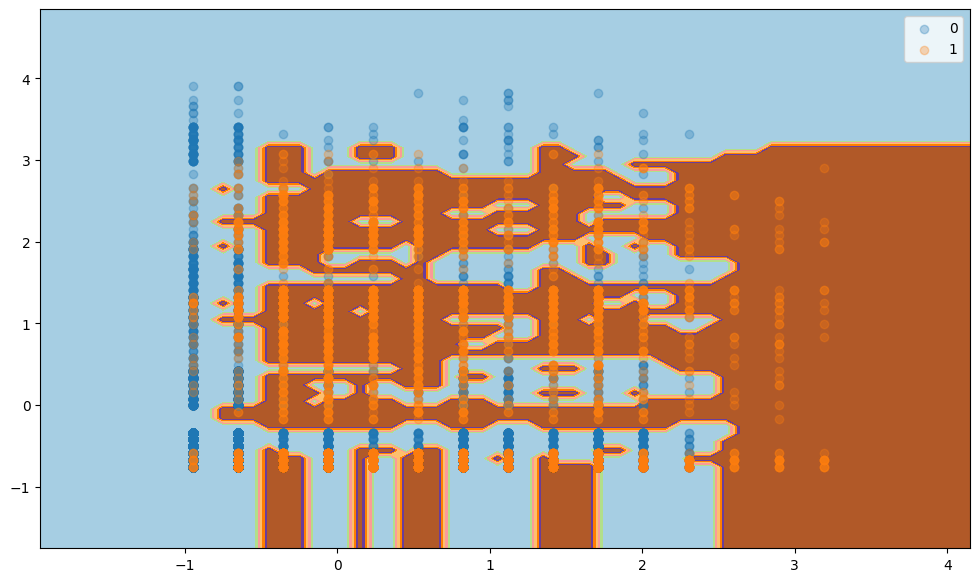

              precision    recall  f1-score   support

           0       0.80      0.97      0.87      3000
           1       0.88      0.50      0.64      1500

    accuracy                           0.81      4500
   macro avg       0.84      0.74      0.76      4500
weighted avg       0.83      0.81      0.80      4500



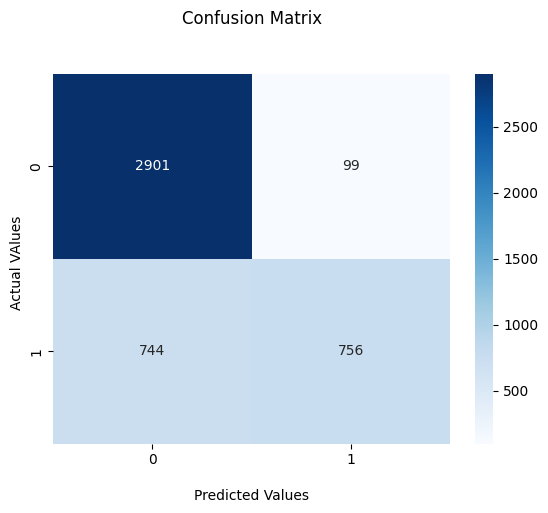

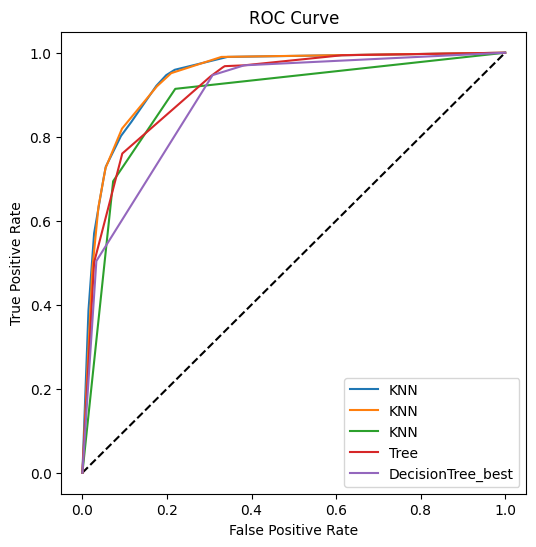

Lowest score


c:\Users\abram\Desktop\Kodilla\learning-git-task\14.Klasyfikacja\plot_classification_surface.py:32: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_plot[row_ix,0], X_plot[row_ix,1], cmap='Paired', alpha=0.3, label= class_value)


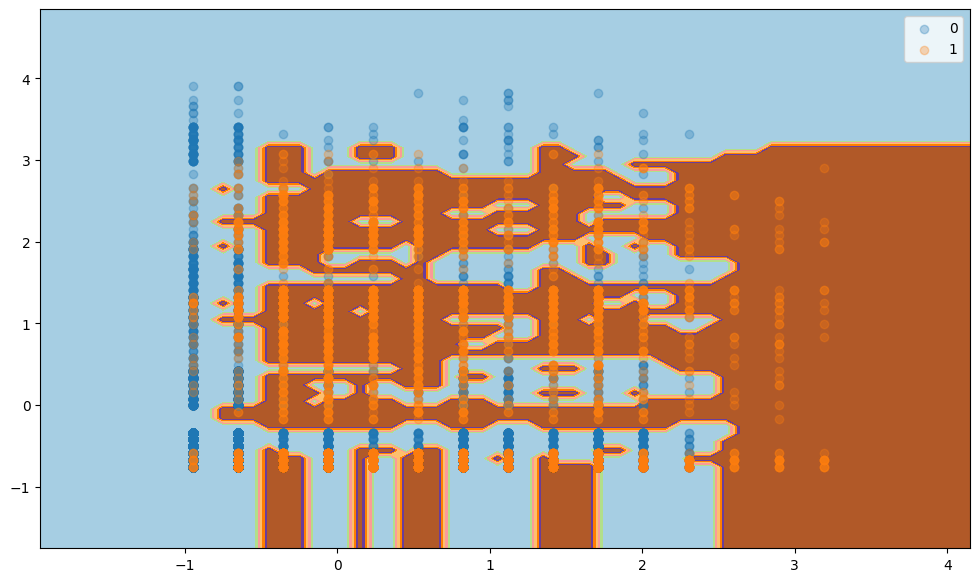

              precision    recall  f1-score   support

           0       0.92      0.91      0.91      3000
           1       0.82      0.85      0.83      1500

    accuracy                           0.89      4500
   macro avg       0.87      0.88      0.87      4500
weighted avg       0.89      0.89      0.89      4500



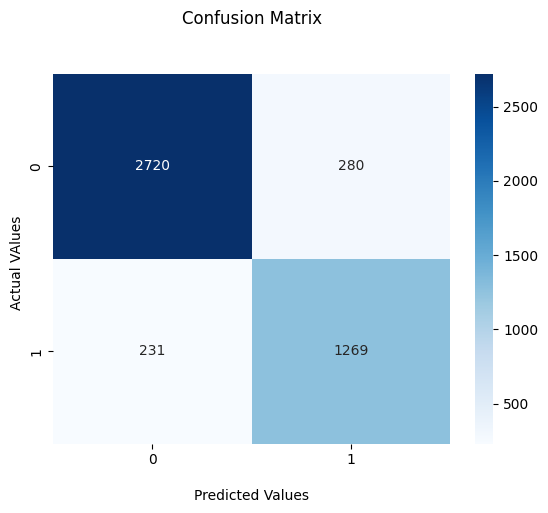

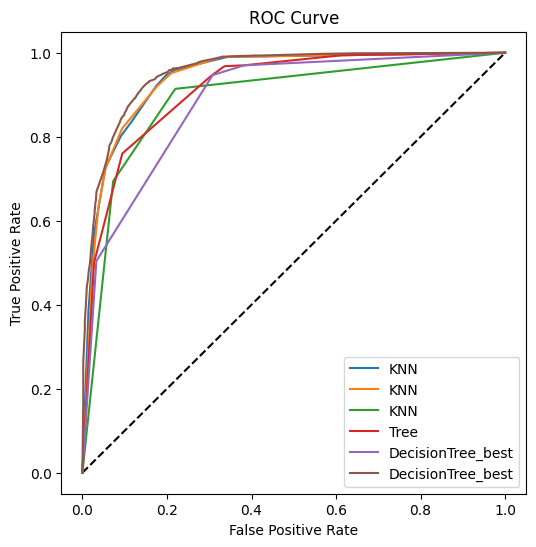

,Model,F1_score,AUC
0,KNN,0.808196,0.942804
1,KNN,0.816611,0.941814
2,KNN,0.754621,0.890182
3,Tree,0.780021,0.915466
4,DecisionTree_best,0.642038,0.887412
5,DecisionTree_best,0.832404,0.953735


In [12]:
best_f1_score_test = -1
lowest_f1_score_test = 10
for max_depth in range(1,20):
    for min_samples_leaf in range(2,20):
        name = f'Tree_depth:{max_depth}_min_sample_leaf:{min_samples_leaf}'
        model_dtc = DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=min_samples_leaf)
        model_dtc.fit(X_train_standardized, y_train)
        prediction_train = model_dtc.predict(X_train_standardized)
        prediction_test = model_dtc.predict(X_test_standardized)
        f1_score_train = f1_score(y_train, prediction_train)
        f1_score_test = f1_score(y_test, prediction_test)
        print(f'for : {name}')
        print('F1 train:', f1_score_train)
        print('F1 test :', f1_score_test)
        if f1_score_test > best_f1_score_test:
            best_f1_score_test = f1_score_test
            best_name = name
        if f1_score_test < lowest_f1_score_test:
            lowest_f1_score_test = f1_score_test
            lowest_name = name

print('for:  ',best_name,'\nBest score F1 test = ', best_f1_score_test)
print('for:  ',lowest_name,'\nLowest score F1 test = ', lowest_f1_score_test)

print('Best score')
model_dtc = DecisionTreeClassifier(max_depth=2,min_samples_leaf=2)
model_dtc.fit(X_train_standardized, y_train)
plot_classification_surface(X_plot=X_train_standardized, y_plot=y_train, trained_model=model_knn)
calculate_metrics(model_dtc, 'DecisionTree_best', X_test_standardized, y_test)
print('Lowest score')
model_dtc = DecisionTreeClassifier(max_depth=10,min_samples_leaf=10)
model_dtc.fit(X_train_standardized, y_train)
plot_classification_surface(X_plot=X_train_standardized, y_plot=y_train, trained_model=model_knn)
calculate_metrics(model_dtc, 'DecisionTree_best', X_test_standardized, y_test)

c:\Users\abram\Desktop\Kodilla\learning-git-task\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\abram\Desktop\Kodilla\learning-git-task\14.Klasyfikacja\plot_classification_surface.py:32: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_plot[row_ix,0], X_plot[row_ix,1], cmap='Paired', alpha=0.3, label= class_value)


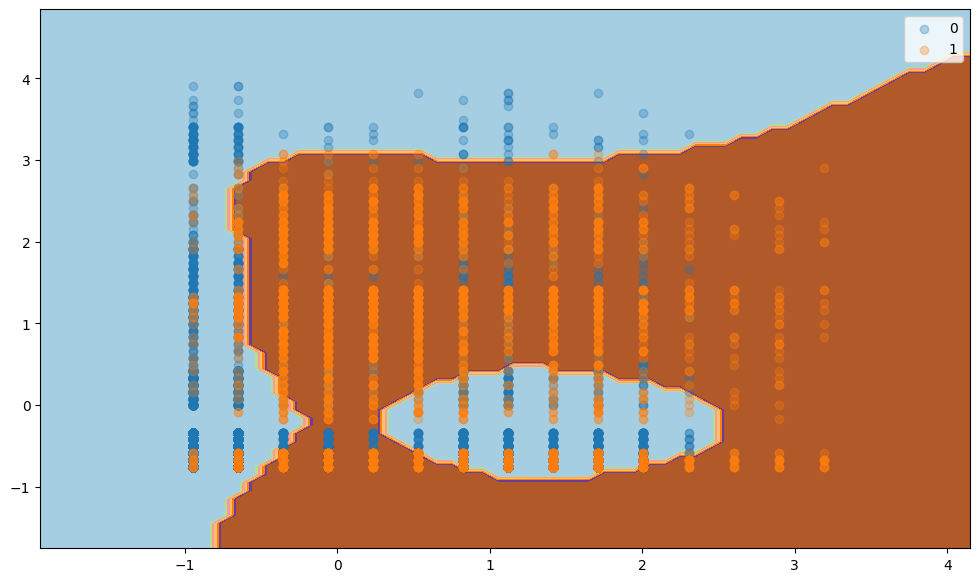

              precision    recall  f1-score   support

           0       0.89      0.90      0.90      3000
           1       0.80      0.79      0.79      1500

    accuracy                           0.86      4500
   macro avg       0.85      0.84      0.85      4500
weighted avg       0.86      0.86      0.86      4500



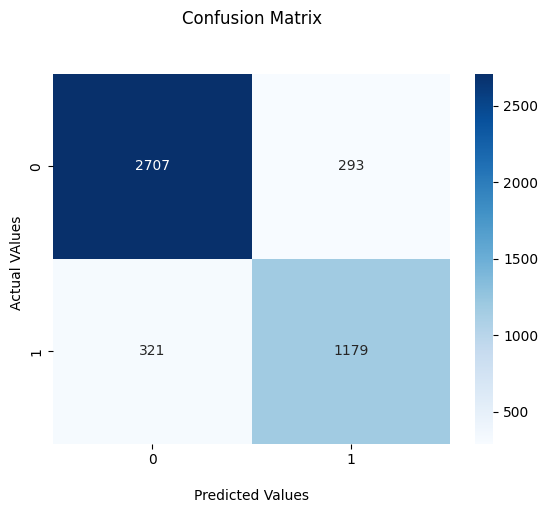

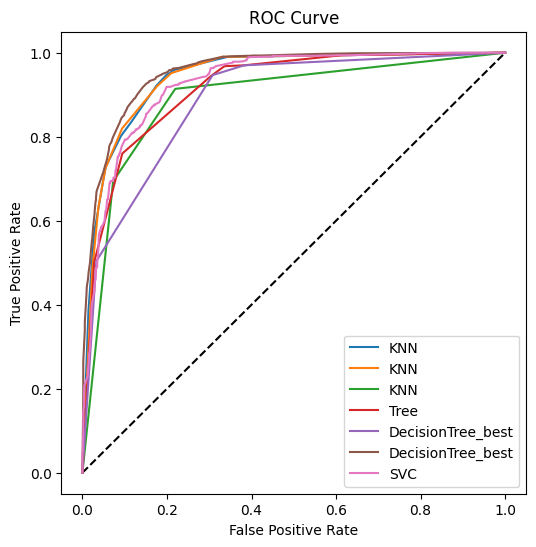

,Model,F1_score,AUC
0,KNN,0.808196,0.942804
1,KNN,0.816611,0.941814
2,KNN,0.754621,0.890182
3,Tree,0.780021,0.915466
4,DecisionTree_best,0.642038,0.887412
5,DecisionTree_best,0.832404,0.953735
6,SVC,0.793405,0.927969


In [13]:
model_svm = SVC(kernel='rbf', probability=True)
model_svm.fit(X_train_standardized, y_train)
plot_classification_surface(X_plot=X_train_standardized, y_plot=y_train, trained_model=model_svm)
calculate_metrics(model_svm, 'SVC', X_test_standardized, y_test)

In [14]:
best_f1_score_test = -1
lowest_f1_score_test = 10
for kernel in ['linear', 'poly', 'rbf']:
    for C in [0.01, 0.1, 1, 10, 100]:
        for gamma in ['auto']:

            name = f'SVC_kernel:{kernel}_C:{C}_gamma:{gamma}'
            model_svc = SVC(kernel=kernel,C=C,gamma=gamma)
            model_svc.fit(X_train_standardized, y_train)
            prediction_train = model_svc.predict(X_train_standardized)
            prediction_test = model_svc.predict(X_test_standardized)
            f1_score_train = f1_score(y_train, prediction_train)
            f1_score_test = f1_score(y_test, prediction_test)
            print(f'for : {name}')
            print('F1 train:', f1_score_train)
            print('F1 test :', f1_score_test)
            if f1_score_test > best_f1_score_test:
                best_f1_score_test = f1_score_test
                best_name = name
            if f1_score_test < lowest_f1_score_test:
                lowest_f1_score_test = f1_score_test
                lowest_name = name

print('for:  ',best_name,'\nBest score F1 test = ', best_f1_score_test)
print('for:  ',lowest_name,'\nLowest score F1 test = ', lowest_f1_score_test)

for : SVC_kernel:linear_C:0.01_gamma:auto
F1 train: 0.572094572094572
F1 test : 0.5842868039664378
for : SVC_kernel:linear_C:0.1_gamma:auto
F1 train: 0.5750410509031199
F1 test : 0.588855421686747
for : SVC_kernel:linear_C:1_gamma:auto
F1 train: 0.5731788079470199
F1 test : 0.5889477668433005
for : SVC_kernel:linear_C:10_gamma:auto
F1 train: 0.5731788079470199
F1 test : 0.5889477668433005
for : SVC_kernel:linear_C:100_gamma:auto
F1 train: 0.5721401295035696
F1 test : 0.5867172675521821
for : SVC_kernel:poly_C:0.01_gamma:auto
F1 train: 0.30540728707356696
F1 test : 0.33544973544973544
for : SVC_kernel:poly_C:0.1_gamma:auto
F1 train: 0.30580046403712297
F1 test : 0.3372093023255814
for : SVC_kernel:poly_C:1_gamma:auto
F1 train: 0.30933086362583934
F1 test : 0.337909186906019
for : SVC_kernel:poly_C:10_gamma:auto
F1 train: 0.3089393237610005
F1 test : 0.337909186906019
for : SVC_kernel:poly_C:100_gamma:auto
F1 train: 0.30580046403712297
F1 test : 0.3370311674590597
for : SVC_kernel:rbf_C:

Best score


c:\Users\abram\Desktop\Kodilla\learning-git-task\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\abram\Desktop\Kodilla\learning-git-task\14.Klasyfikacja\plot_classification_surface.py:32: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_plot[row_ix,0], X_plot[row_ix,1], cmap='Paired', alpha=0.3, label= class_value)


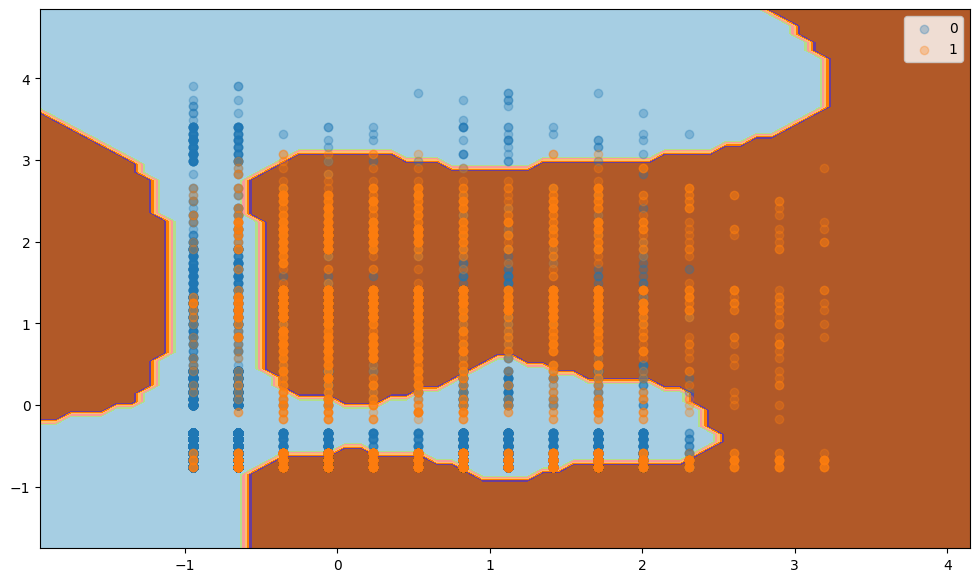

              precision    recall  f1-score   support

           0       0.89      0.92      0.90      3000
           1       0.82      0.77      0.80      1500

    accuracy                           0.87      4500
   macro avg       0.85      0.84      0.85      4500
weighted avg       0.87      0.87      0.87      4500



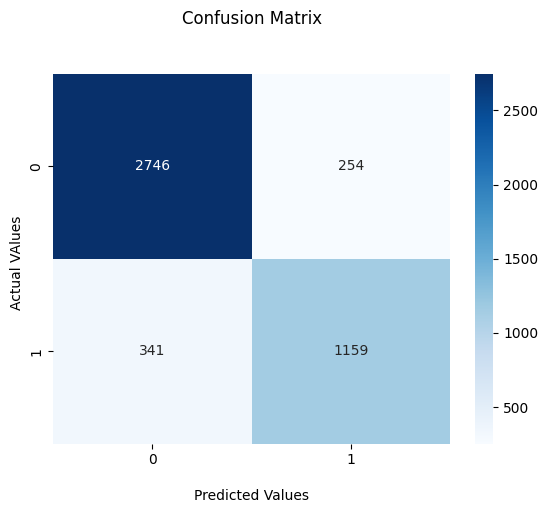

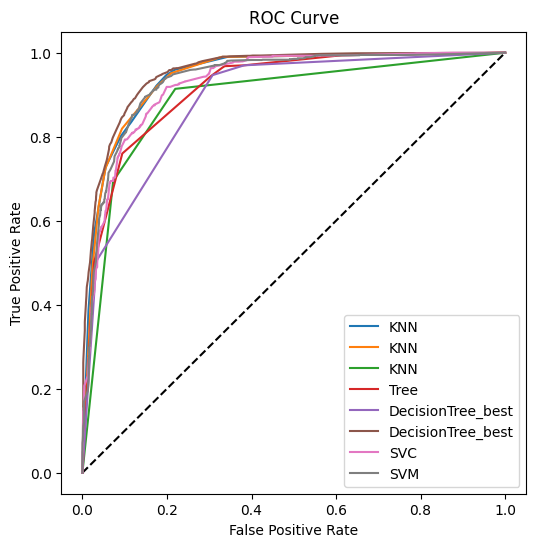

Lowest score


c:\Users\abram\Desktop\Kodilla\learning-git-task\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\abram\Desktop\Kodilla\learning-git-task\14.Klasyfikacja\plot_classification_surface.py:32: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_plot[row_ix,0], X_plot[row_ix,1], cmap='Paired', alpha=0.3, label= class_value)


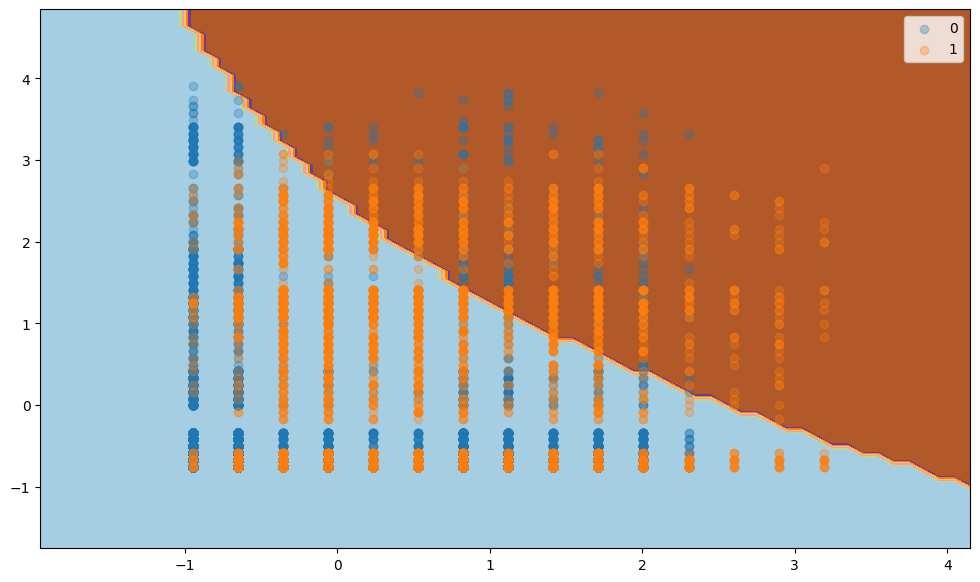

              precision    recall  f1-score   support

           0       0.71      0.98      0.82      3000
           1       0.81      0.21      0.34      1500

    accuracy                           0.72      4500
   macro avg       0.76      0.59      0.58      4500
weighted avg       0.75      0.72      0.66      4500



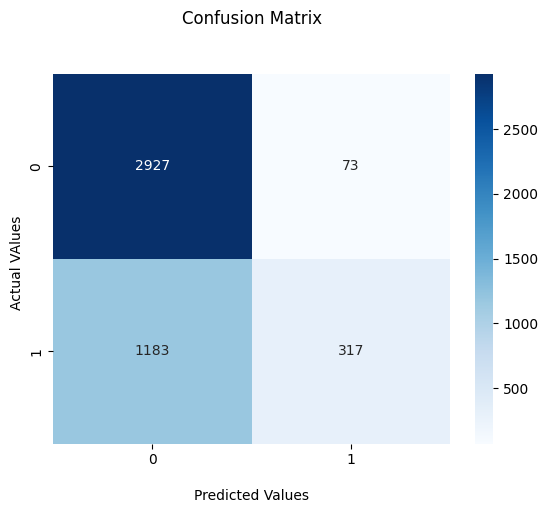

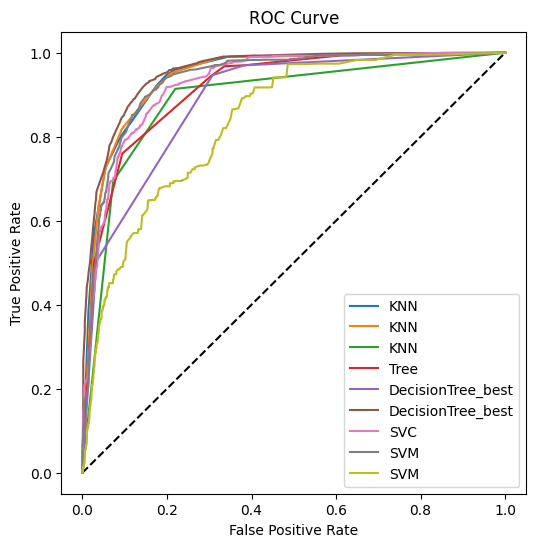

,Model,F1_score,AUC
0,KNN,0.808196,0.942804
1,KNN,0.816611,0.941814
2,KNN,0.754621,0.890182
3,Tree,0.780021,0.915466
4,DecisionTree_best,0.642038,0.887412
5,DecisionTree_best,0.832404,0.953735
6,SVC,0.793405,0.927969
7,SVM,0.795743,0.934958
8,SVM,0.335450,0.837932


In [15]:
print('Best score')
model_svc = SVC(kernel='rbf',C=100,gamma=gamma,probability=True)
model_svc.fit(X_train_standardized, y_train)
plot_classification_surface(X_plot=X_train_standardized, y_plot=y_train, trained_model=model_svc)
calculate_metrics(model_svc, 'SVM', X_test_standardized, y_test)
print('Lowest score')
model_svc = SVC(kernel='poly',C=0.01,gamma=gamma,probability=True)
model_svc.fit(X_train_standardized, y_train)
plot_classification_surface(X_plot=X_train_standardized, y_plot=y_train, trained_model=model_svc)
calculate_metrics(model_svc, 'SVM', X_test_standardized, y_test)

c:\Users\abram\Desktop\Kodilla\learning-git-task\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\abram\Desktop\Kodilla\learning-git-task\14.Klasyfikacja\plot_classification_surface.py:32: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_plot[row_ix,0], X_plot[row_ix,1], cmap='Paired', alpha=0.3, label= class_value)


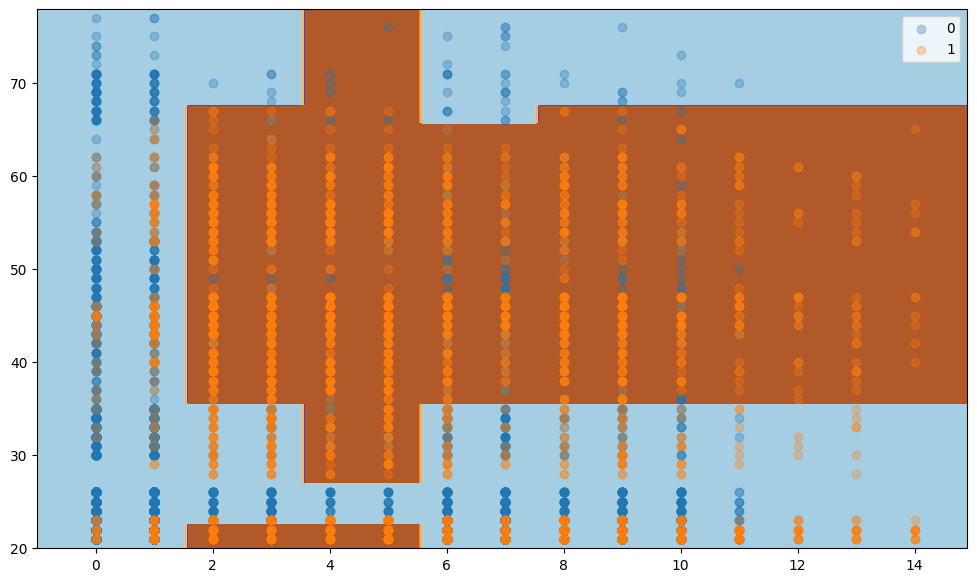

              precision    recall  f1-score   support

           0       0.86      0.94      0.90      3000
           1       0.86      0.70      0.77      1500

    accuracy                           0.86      4500
   macro avg       0.86      0.82      0.83      4500
weighted avg       0.86      0.86      0.86      4500



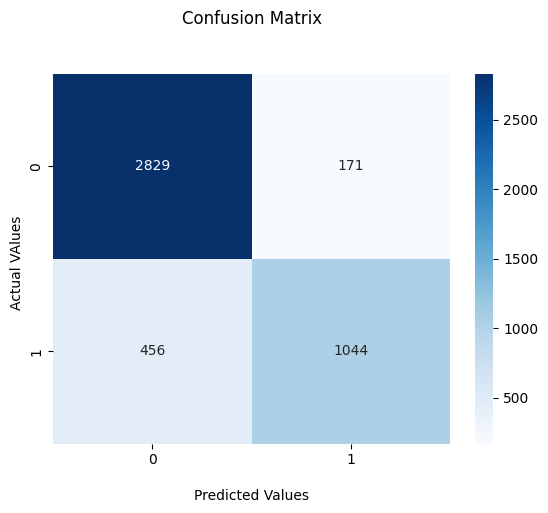

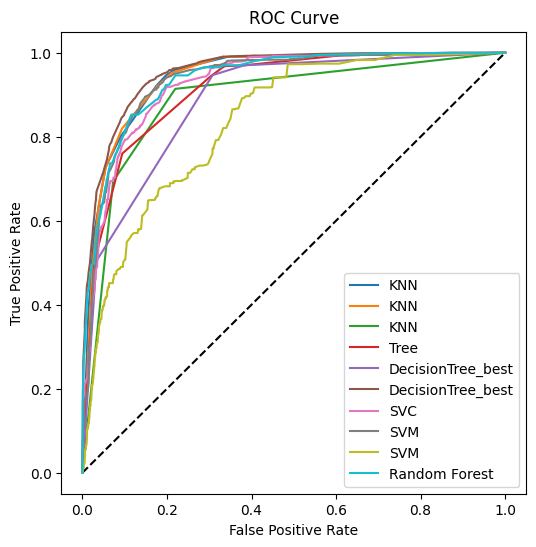

,Model,F1_score,AUC
0,KNN,0.808196,0.942804
1,KNN,0.816611,0.941814
2,KNN,0.754621,0.890182
3,Tree,0.780021,0.915466
4,DecisionTree_best,0.642038,0.887412
5,DecisionTree_best,0.832404,0.953735
6,SVC,0.793405,0.927969
7,SVM,0.795743,0.934958
8,SVM,0.335450,0.837932
9,Random Forest,0.769061,0.938198


In [16]:
from sklearn.ensemble import RandomForestClassifier

model_forest = RandomForestClassifier(n_estimators=1000, max_depth=3, min_samples_leaf=int(X_train.shape[0]*0.001))
model_forest.fit(X_train, y_train)
plot_classification_surface(X_plot=np.array(X_train), y_plot=y_train, trained_model=model_forest)
calculate_metrics(model_forest, 'Random Forest', X_test, y_test)

In [17]:
best_f1_score_test = -1
lowest_f1_score_test = 10

for n_estimators in [10, 100, 500, 1000]:
    for max_depth in [2, 3, 5, 10, None]:
        
            name = (
                f'RandomForest_n:{n_estimators}_depth:{max_depth}')

            model_forest = RandomForestClassifier(n_estimators=n_estimators,max_depth=max_depth,min_samples_leaf=0.001)
            model_forest.fit(X_train, y_train)
            prediction_train = model_forest.predict(X_train)
            prediction_test = model_forest.predict(X_test)
            f1_score_train = f1_score(y_train, prediction_train)
            f1_score_test = f1_score(y_test, prediction_test)
            print(f'for: {name}')
            print('F1 train:', f1_score_train)
            print('F1 test :', f1_score_test)
            if f1_score_test > best_f1_score_test:
                best_f1_score_test = f1_score_test
                best_name = name

            if f1_score_test < lowest_f1_score_test:
                lowest_f1_score_test = f1_score_test
                lowest_name = name

print('for:  ',best_name,'\nBest score F1 test = ', best_f1_score_test)
print('for:  ',lowest_name,'\nLowest score F1 test = ', lowest_f1_score_test)

for: RandomForest_n:10_depth:2
F1 train: 0.6174446717500465
F1 test : 0.6420382165605095
for: RandomForest_n:10_depth:3
F1 train: 0.7741270075143657
F1 test : 0.7778532608695652
for: RandomForest_n:10_depth:5
F1 train: 0.784629981024668
F1 test : 0.7805413313825896
for: RandomForest_n:10_depth:10
F1 train: 0.841806305026981
F1 test : 0.8330058939096268
for: RandomForest_n:10_depth:None
F1 train: 0.842268186295202
F1 test : 0.8289047310434219
for: RandomForest_n:100_depth:2
F1 train: 0.7525706940874036
F1 test : 0.7574972232506479
for: RandomForest_n:100_depth:3
F1 train: 0.758051464638291
F1 test : 0.7605947955390334
for: RandomForest_n:100_depth:5
F1 train: 0.8324989271921042
F1 test : 0.8248847926267281
for: RandomForest_n:100_depth:10
F1 train: 0.8407825217763816
F1 test : 0.8266315095583389
for: RandomForest_n:100_depth:None
F1 train: 0.8418199971473399
F1 test : 0.8301018731514952
for: RandomForest_n:500_depth:2
F1 train: 0.7525706940874036
F1 test : 0.7574972232506479
for: Random

Best score


c:\Users\abram\Desktop\Kodilla\learning-git-task\14.Klasyfikacja\plot_classification_surface.py:32: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_plot[row_ix,0], X_plot[row_ix,1], cmap='Paired', alpha=0.3, label= class_value)


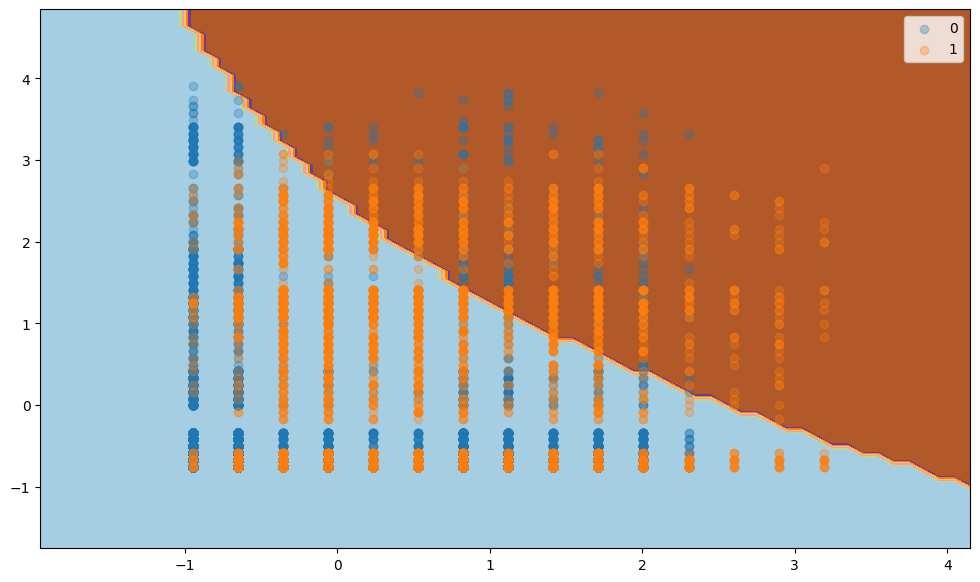

              precision    recall  f1-score   support

           0       0.92      0.90      0.91      3000
           1       0.81      0.84      0.83      1500

    accuracy                           0.88      4500
   macro avg       0.87      0.87      0.87      4500
weighted avg       0.88      0.88      0.88      4500



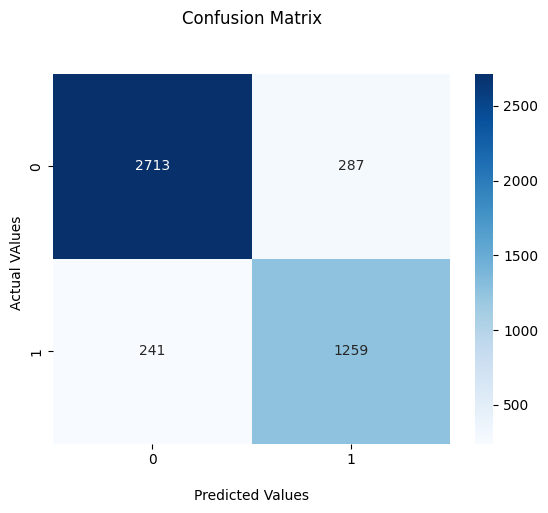

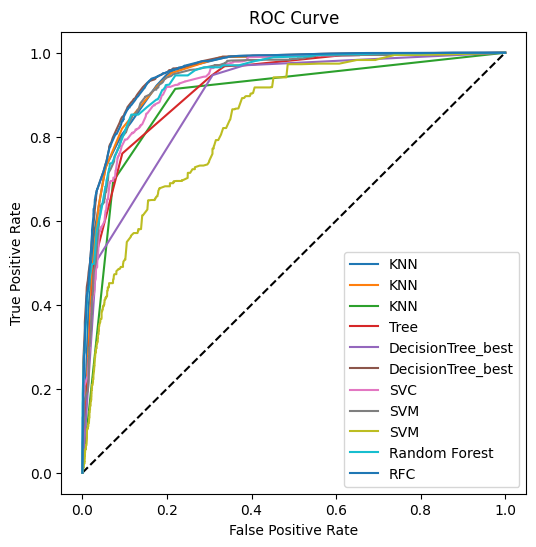

Lowest score


c:\Users\abram\Desktop\Kodilla\learning-git-task\14.Klasyfikacja\plot_classification_surface.py:32: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_plot[row_ix,0], X_plot[row_ix,1], cmap='Paired', alpha=0.3, label= class_value)


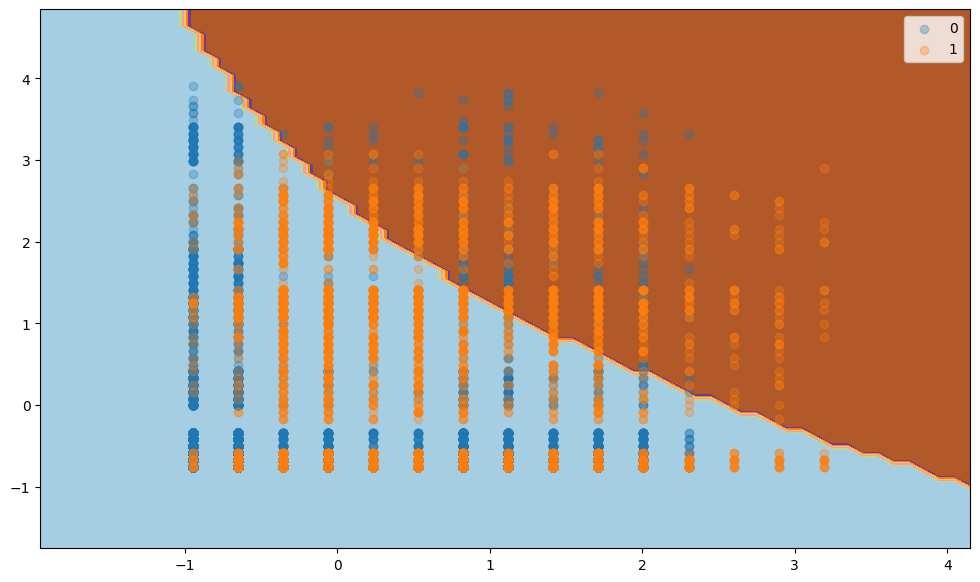

              precision    recall  f1-score   support

           0       0.80      0.97      0.87      3000
           1       0.88      0.50      0.64      1500

    accuracy                           0.81      4500
   macro avg       0.84      0.74      0.76      4500
weighted avg       0.83      0.81      0.80      4500



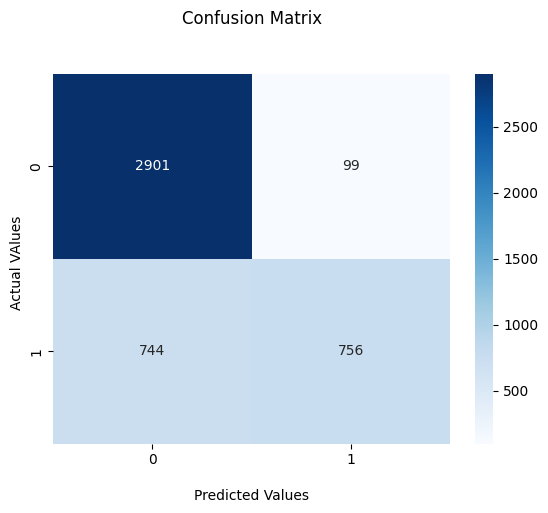

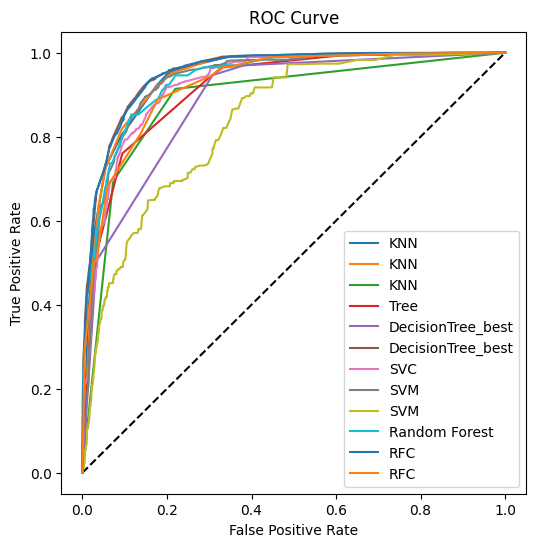

,Model,F1_score,AUC
0,KNN,0.808196,0.942804
1,KNN,0.816611,0.941814
2,KNN,0.754621,0.890182
3,Tree,0.780021,0.915466
4,DecisionTree_best,0.642038,0.887412
5,DecisionTree_best,0.832404,0.953735
6,SVC,0.793405,0.927969
7,SVM,0.795743,0.934958
8,SVM,0.335450,0.837932
9,Random Forest,0.769061,0.938198


In [18]:
print('Best score')
model_rfc = RandomForestClassifier(n_estimators=10,max_depth=None,min_samples_leaf=0.001)
model_rfc.fit(X_train_standardized, y_train)
plot_classification_surface(X_plot=X_train_standardized, y_plot=y_train, trained_model=model_svc)
calculate_metrics(model_rfc, 'RFC', X_test_standardized, y_test)
print('Lowest score')
model_rfc = RandomForestClassifier(n_estimators=10,max_depth=2,min_samples_leaf=0.001)
model_rfc.fit(X_train_standardized, y_train)
plot_classification_surface(X_plot=X_train_standardized, y_plot=y_train, trained_model=model_svc)
calculate_metrics(model_rfc, 'RFC', X_test_standardized, y_test)

c:\Users\abram\Desktop\Kodilla\learning-git-task\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
c:\Users\abram\Desktop\Kodilla\learning-git-task\14.Klasyfikacja\plot_classification_surface.py:32: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_plot[row_ix,0], X_plot[row_ix,1], cmap='Paired', alpha=0.3, label= class_value)


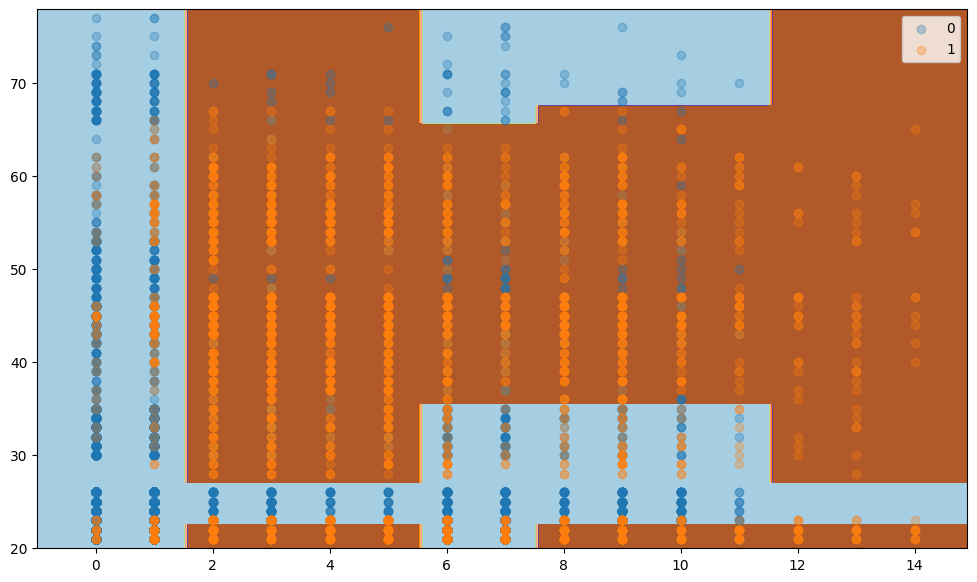

c:\Users\abram\Desktop\Kodilla\learning-git-task\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
c:\Users\abram\Desktop\Kodilla\learning-git-task\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.69      0.92      0.79      3000
           1       0.55      0.19      0.28      1500

    accuracy                           0.68      4500
   macro avg       0.62      0.56      0.54      4500
weighted avg       0.65      0.68      0.62      4500



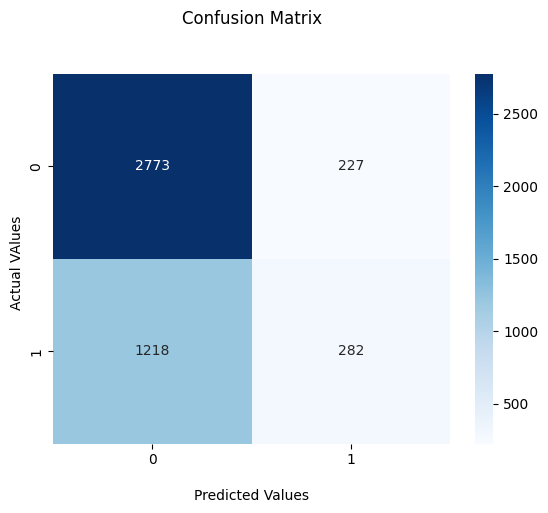

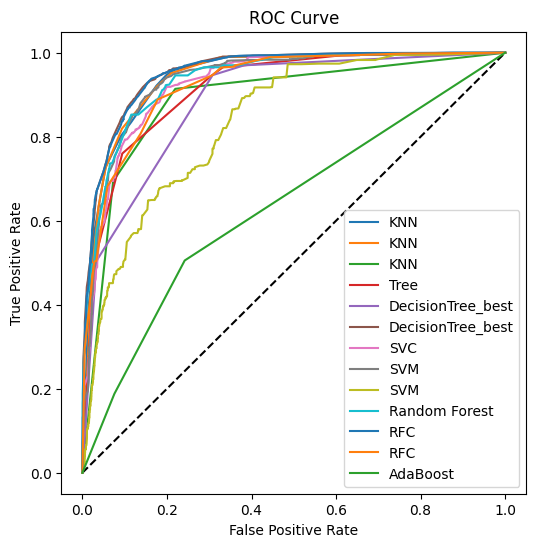

,Model,F1_score,AUC
0,KNN,0.808196,0.942804
1,KNN,0.816611,0.941814
2,KNN,0.754621,0.890182
3,Tree,0.780021,0.915466
4,DecisionTree_best,0.642038,0.887412
5,DecisionTree_best,0.832404,0.953735
6,SVC,0.793405,0.927969
7,SVM,0.795743,0.934958
8,SVM,0.335450,0.837932
9,Random Forest,0.769061,0.938198


In [19]:
from sklearn.ensemble import AdaBoostClassifier

model_adaboost = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=50)
model_adaboost.fit(X_train, y_train)
plot_classification_surface(X_plot=np.array(X_train), y_plot=y_train, trained_model=model_adaboost)
calculate_metrics(model_adaboost, 'AdaBoost', X_test_standardized, y_test)

for: AdaBoost_n_estimators:10
F1 train: 0.7987624428302394
F1 test : 0.7933832709113608


c:\Users\abram\Desktop\Kodilla\learning-git-task\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
c:\Users\abram\Desktop\Kodilla\learning-git-task\14.Klasyfikacja\plot_classification_surface.py:32: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_plot[row_ix,0], X_plot[row_ix,1], cmap='Paired', alpha=0.3, label= class_value)


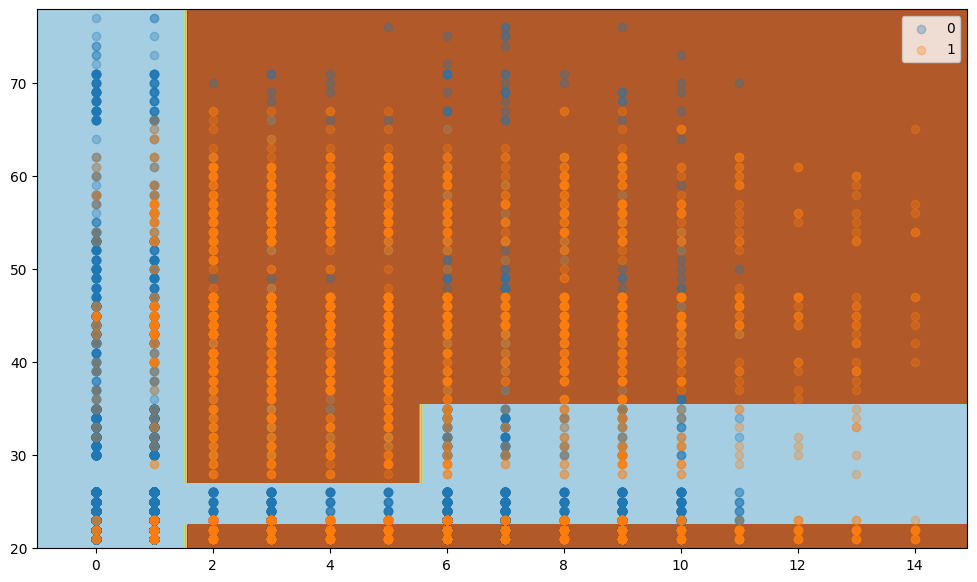

for: AdaBoost_n_estimators:50
F1 train: 0.8146123975262477
F1 test : 0.8092868988391376


c:\Users\abram\Desktop\Kodilla\learning-git-task\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
c:\Users\abram\Desktop\Kodilla\learning-git-task\14.Klasyfikacja\plot_classification_surface.py:32: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_plot[row_ix,0], X_plot[row_ix,1], cmap='Paired', alpha=0.3, label= class_value)


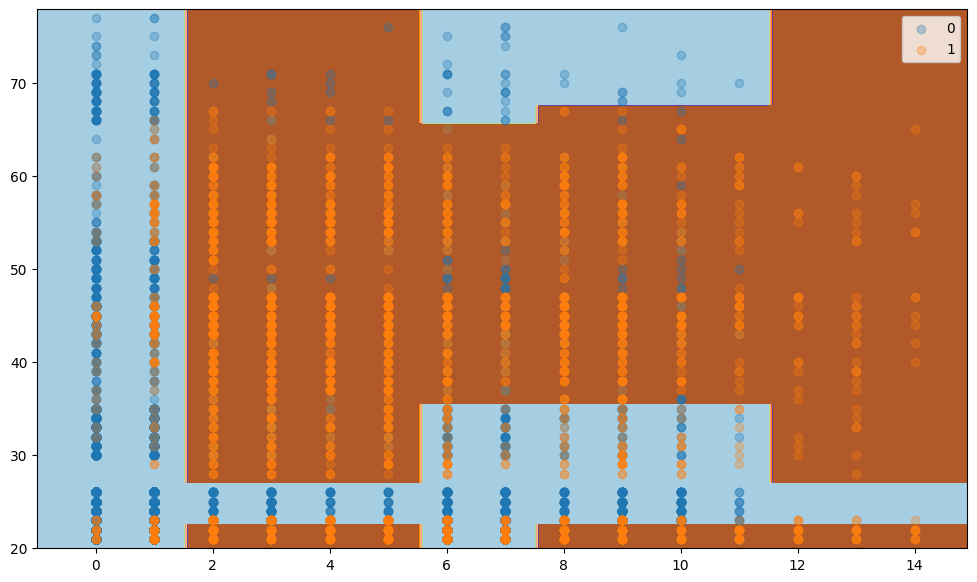

for: AdaBoost_n_estimators:100
F1 train: 0.8166906474820144
F1 test : 0.812975835815955


c:\Users\abram\Desktop\Kodilla\learning-git-task\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
c:\Users\abram\Desktop\Kodilla\learning-git-task\14.Klasyfikacja\plot_classification_surface.py:32: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_plot[row_ix,0], X_plot[row_ix,1], cmap='Paired', alpha=0.3, label= class_value)


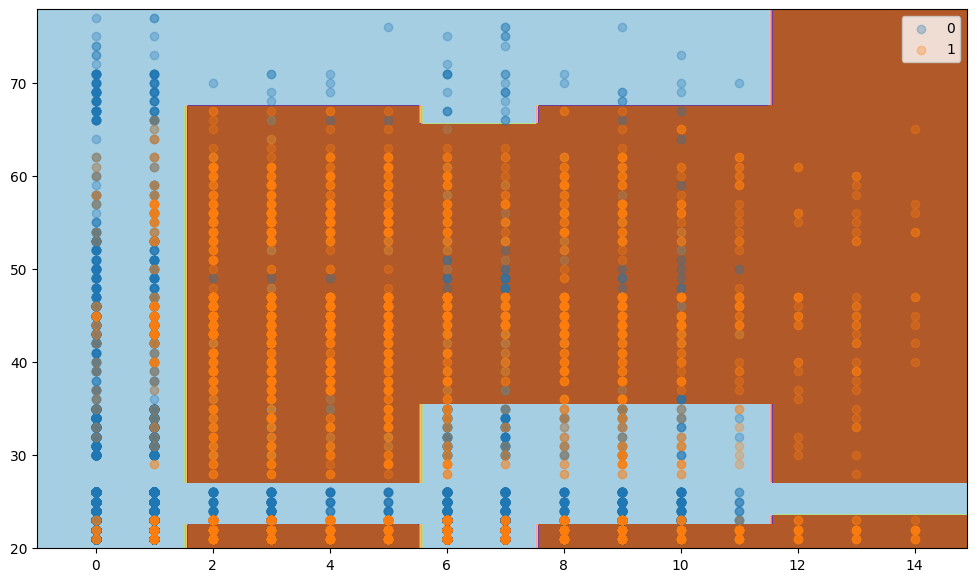

for: AdaBoost_n_estimators:500
F1 train: 0.8338351254480286
F1 test : 0.8272907053394858


c:\Users\abram\Desktop\Kodilla\learning-git-task\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
c:\Users\abram\Desktop\Kodilla\learning-git-task\14.Klasyfikacja\plot_classification_surface.py:32: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_plot[row_ix,0], X_plot[row_ix,1], cmap='Paired', alpha=0.3, label= class_value)


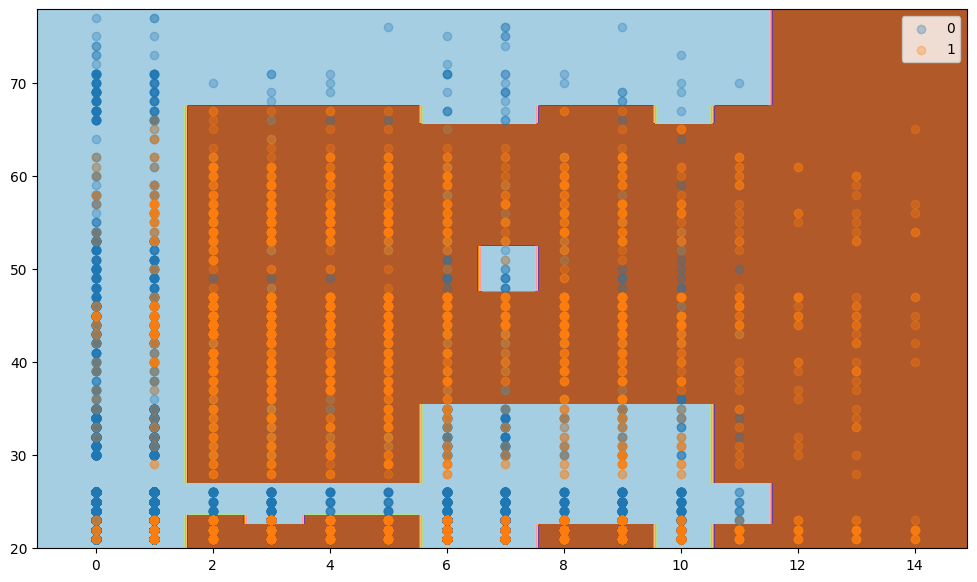

for: AdaBoost_n_estimators:1000
F1 train: 0.8369221935113408
F1 test : 0.8302011210023079


c:\Users\abram\Desktop\Kodilla\learning-git-task\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
c:\Users\abram\Desktop\Kodilla\learning-git-task\14.Klasyfikacja\plot_classification_surface.py:32: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_plot[row_ix,0], X_plot[row_ix,1], cmap='Paired', alpha=0.3, label= class_value)


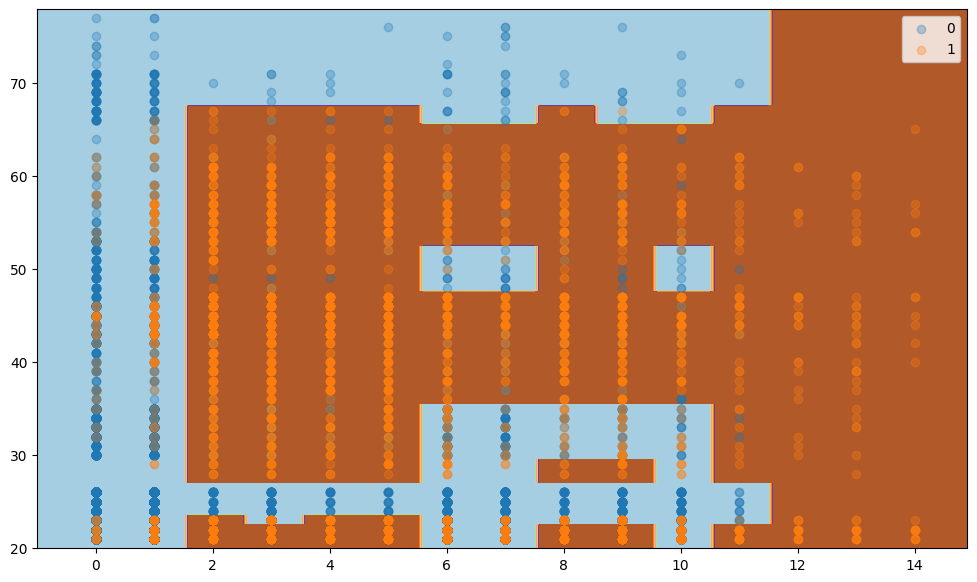

for: AdaBoost_n_estimators:1000 
Best score F1 test = 0.8302011210023079
for: AdaBoost_n_estimators:10 
Lowest score F1 test = 0.7933832709113608


In [20]:
best_f1_score_test = -1
lowest_f1_score_test = 10

for n_estimators in [10, 50, 100, 500, 1000]:

    name = f'AdaBoost_n_estimators:{n_estimators}'

    model_adaboost = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=n_estimators
    )

    model_adaboost.fit(X_train, y_train)

    prediction_train = model_adaboost.predict(X_train)
    prediction_test = model_adaboost.predict(X_test)

    f1_score_train = f1_score(y_train, prediction_train)
    f1_score_test = f1_score(y_test, prediction_test)

    print(f'for: {name}')
    print('F1 train:', f1_score_train)
    print('F1 test :', f1_score_test)

    plot_classification_surface(
        X_plot=np.array(X_train),
        y_plot=y_train,
        trained_model=model_adaboost
    )

    if f1_score_test > best_f1_score_test:
        best_f1_score_test = f1_score_test
        best_name = name

    if f1_score_test < lowest_f1_score_test:
        lowest_f1_score_test = f1_score_test
        lowest_name = name


print('for:', best_name,
      '\nBest score F1 test =', best_f1_score_test)

print('for:', lowest_name,
      '\nLowest score F1 test =', lowest_f1_score_test)

c:\Users\abram\Desktop\Kodilla\learning-git-task\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\abram\Desktop\Kodilla\learning-git-task\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\abram\Desktop\Kodilla\learning-git-task\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
c:\Users\abram\Desktop\Kodilla\learning-git-task\14.Klasyfikacja\plot_classification_surface.py:32: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_plot[row_ix,0], X_plot[row_ix,1], cmap='Paired', alpha=0.3, label= class_value)


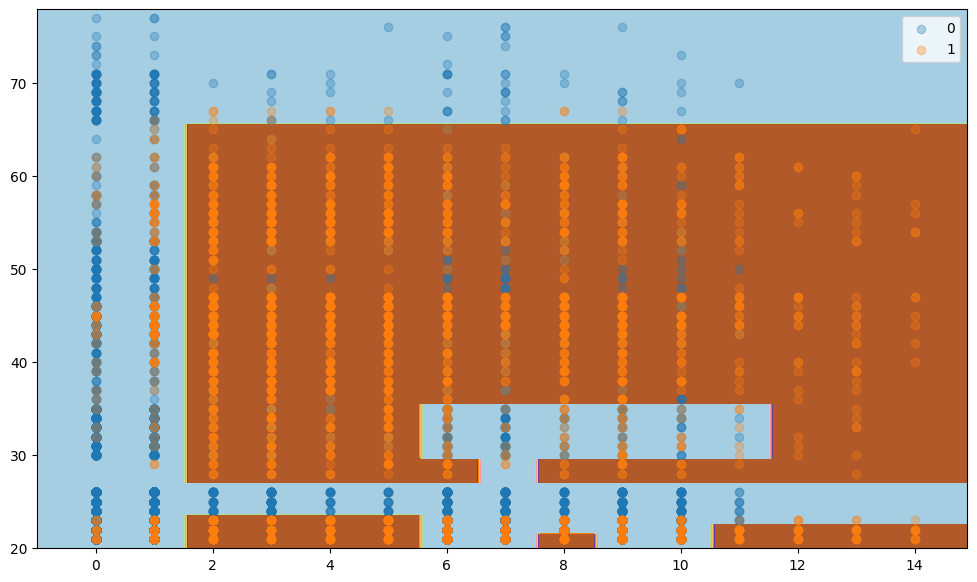

              precision    recall  f1-score   support

           0       0.90      0.92      0.91      3000
           1       0.83      0.79      0.81      1500

    accuracy                           0.88      4500
   macro avg       0.87      0.86      0.86      4500
weighted avg       0.88      0.88      0.88      4500



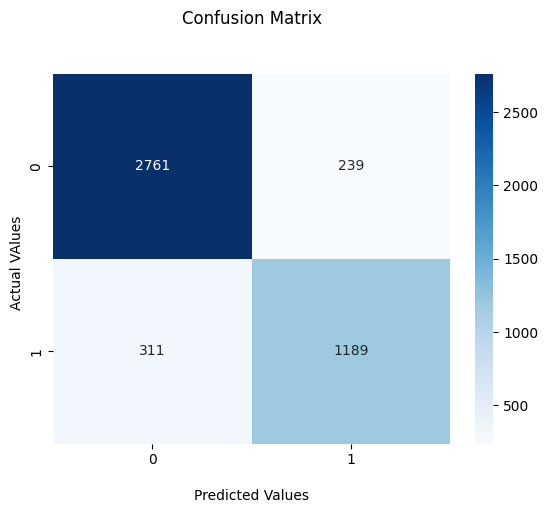

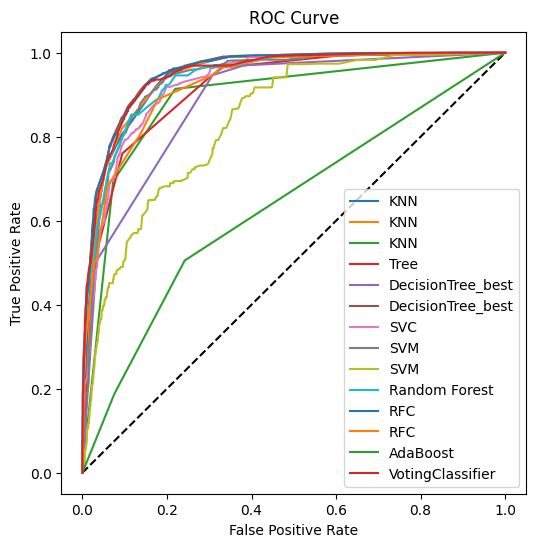

,Model,F1_score,AUC
0,KNN,0.808196,0.942804
1,KNN,0.816611,0.941814
2,KNN,0.754621,0.890182
3,Tree,0.780021,0.915466
4,DecisionTree_best,0.642038,0.887412
5,DecisionTree_best,0.832404,0.953735
6,SVC,0.793405,0.927969
7,SVM,0.795743,0.934958
8,SVM,0.335450,0.837932
9,Random Forest,0.769061,0.938198


In [21]:
from sklearn.ensemble import VotingClassifier

model_voting = VotingClassifier(estimators=[('Tree', model_tree),
                                            ('Random Forest', model_forest),
                                            ('AdaBoost', model_adaboost)],
                                voting='soft')

model_voting.fit(X_train, y_train)
plot_classification_surface(X_plot=np.array(X_train), y_plot=y_train, trained_model=model_voting)
calculate_metrics(model_voting, 'VotingClassifier', X_test, y_test)

for: VotingClassifier_voting:hard
F1 train: 0.8366350846971002
F1 test : 0.8303630363036304


c:\Users\abram\Desktop\Kodilla\learning-git-task\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\abram\Desktop\Kodilla\learning-git-task\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\abram\Desktop\Kodilla\learning-git-task\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
c:\Users\abram\Desktop\Kodilla\learning-git-task\14.Klasyfikacja\plot_classification_surface.py:32: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_plot[row_ix,0], X_plot[row_ix,1], cmap='Paired', alpha=0.3, label= class_value)


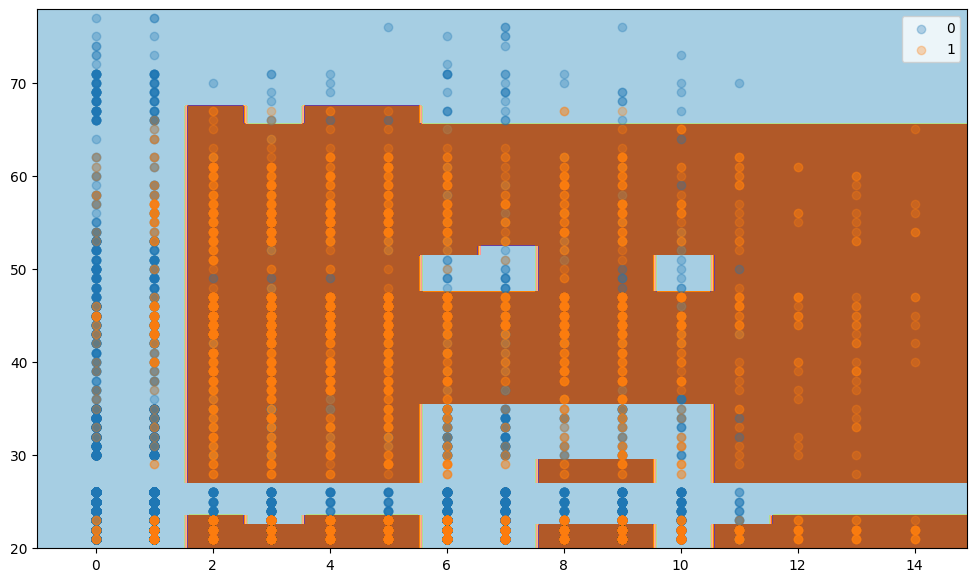

for: VotingClassifier_voting:soft
F1 train: 0.8196333530455352
F1 test : 0.8121584699453552


c:\Users\abram\Desktop\Kodilla\learning-git-task\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\abram\Desktop\Kodilla\learning-git-task\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\abram\Desktop\Kodilla\learning-git-task\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
c:\Users\abram\Desktop\Kodilla\learning-git-task\14.Klasyfikacja\plot_classification_surface.py:32: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_plot[row_ix,0], X_plot[row_ix,1], cmap='Paired', alpha=0.3, label= class_value)


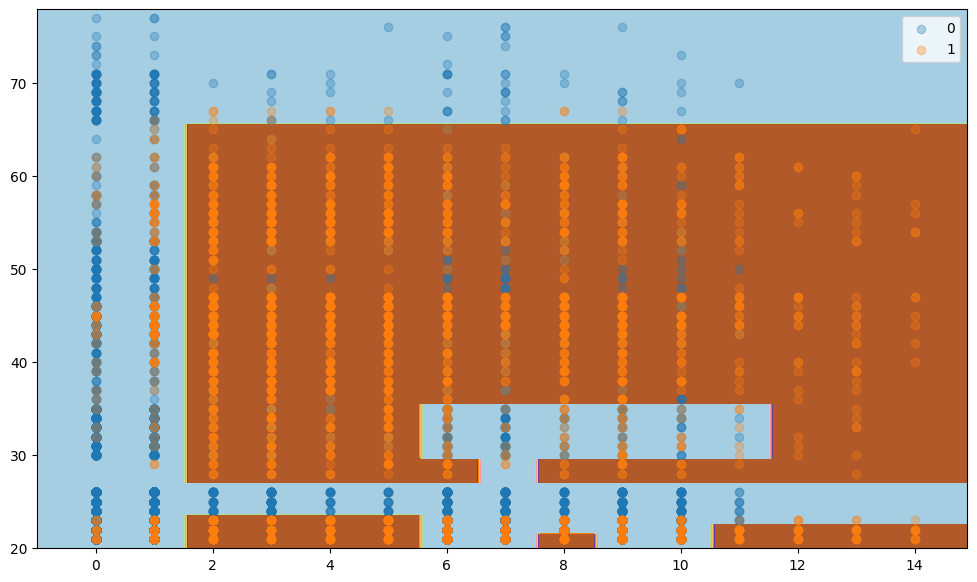

for: VotingClassifier_voting:hard 
Best score F1 test = 0.8303630363036304
for: VotingClassifier_voting:soft 
Lowest score F1 test = 0.8121584699453552


In [22]:
best_f1_score_test = -1
lowest_f1_score_test = 10

for voting_type in ['hard', 'soft']:

    name = f'VotingClassifier_voting:{voting_type}'

    model_voting = VotingClassifier(
        estimators=[
            ('Tree', model_tree),
            ('Random Forest', model_forest),
            ('AdaBoost', model_adaboost)
        ],
        voting=voting_type
    )

    model_voting.fit(X_train, y_train)

    prediction_train = model_voting.predict(X_train)
    prediction_test = model_voting.predict(X_test)

    f1_score_train = f1_score(y_train, prediction_train)
    f1_score_test = f1_score(y_test, prediction_test)

    print(f'for: {name}')
    print('F1 train:', f1_score_train)
    print('F1 test :', f1_score_test)

    plot_classification_surface(
        X_plot=np.array(X_train),
        y_plot=y_train,
        trained_model=model_voting
    )

    if f1_score_test > best_f1_score_test:
        best_f1_score_test = f1_score_test
        best_name = name

    if f1_score_test < lowest_f1_score_test:
        lowest_f1_score_test = f1_score_test
        lowest_name = name


print(
    'for:', best_name,
    '\nBest score F1 test =', best_f1_score_test
)

print(
    'for:', lowest_name,
    '\nLowest score F1 test =', lowest_f1_score_test
)

In [23]:
from sklearn.model_selection import GridSearchCV

random_forest = RandomForestClassifier(n_estimators=1000, n_jobs=-1)
params_rf = {'max_depth': [3, 5, 10, 20],
             'min_samples_leaf': [3, 5, 10, 15]}
rf_gridsearch = GridSearchCV(random_forest,
                             params_rf,
                             scoring='f1_macro',
                             cv=5,
                             verbose=10, n_jobs=-1)
rf_gridsearch.fit(X_train, y_train)
print('\nBest hyperparameter:', rf_gridsearch.best_params_)
rf_model_v2 = rf_gridsearch.best_estimator_

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best hyperparameter: {'max_depth': 10, 'min_samples_leaf': 10}


In [6]:
from calculate_param_models import calculate_param_models
best_models = calculate_param_models(X_train=X_train_standardized,y_train=y_train)
best_models


===== Logistic Regression =====
Fitting 5 folds for each of 5 candidates, totalling 25 fits

===== KNN =====
Fitting 5 folds for each of 12 candidates, totalling 60 fits

===== Decision Tree =====
Fitting 5 folds for each of 16 candidates, totalling 80 fits

===== Random Forest =====
Fitting 5 folds for each of 16 candidates, totalling 80 fits

===== SVC =====
Fitting 5 folds for each of 12 candidates, totalling 60 fits

===== AdaBoost =====
Fitting 5 folds for each of 9 candidates, totalling 45 fits


{'Logistic Regression': LogisticRegression(C=1, max_iter=1000),
 'KNN': KNeighborsClassifier(n_neighbors=9, p=1),
 'Decision Tree': DecisionTreeClassifier(max_depth=10, min_samples_leaf=15),
 'Random Forest': RandomForestClassifier(max_depth=20, min_samples_leaf=10, n_estimators=1000,
                        n_jobs=-1),
 'SVC': SVC(C=1),
 'AdaBoost': AdaBoostClassifier(learning_rate=1, n_estimators=200)}